In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings


from sklearn import datasets
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, pdist, cdist


import dask.dataframe as dd
from dask.distributed import Client
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg




plt.style.use('seaborn-v0_8')
warnings.filterwarnings('ignore')


In [2]:
# zadanie 1

"""
Semi-supervised learning i Cluster Assumption

problem, który rozwiązujemy:
overfitting, który płynie z tego, że w standardowych klasyfikatorach (np. Random Forest)
uczy sie na grnaicy decyzyjnej tylko na danych etykietowanych.
5% - granica bedzie bardzo niedokladna (overfitting)

K-Means nie potrzebuje etykiet. Patrzy tylko na ksztalt danych w przestrzeni

Cluster Assumption -> zakładamy, że punkty znajdujące się w tym samym klastrze prawdopodpbonie
należą do tej samej klasy.

Nasz algorytm:
a) grupowanie (ignorujemy etykiety i KMeansem znajdujemy 10 naturalnych grup (0-10))
b) etykietowanie klastrów. (na podstawie tych 5%). jezeli w ktoryms klastrze, wiekszsoc punktow
to siodemki no to ten klaster to 7
c) propagacja: pozostalym punktom w klastrze tez to przypisujemy
"""

'\nSemi-supervised learning i Cluster Assumption\n\nproblem, który rozwiązujemy:\noverfitting, który płynie z tego, że w standardowych klasyfikatorach (np. Random Forest)\nuczy sie na grnaicy decyzyjnej tylko na danych etykietowanych.\n5% - granica bedzie bardzo niedokladna (overfitting)\n\nK-Means nie potrzebuje etykiet. Patrzy tylko na ksztalt danych w przestrzeni\n\nCluster Assumption -> zakładamy, że punkty znajdujące się w tym samym klastrze prawdopodpbonie\nnależą do tej samej klasy.\n\nNasz algorytm:\na) grupowanie (ignorujemy etykiety i KMeansem znajdujemy 10 naturalnych grup (0-10))\nb) etykietowanie klastrów. (na podstawie tych 5%). jezeli w ktoryms klastrze, wiekszsoc punktow\nto siodemki no to ten klaster to 7\nc) propagacja: pozostalym punktom w klastrze tez to przypisujemy\n'

In [3]:
# przygotowanie danych:

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from scipy.stats import mode

digits = load_digits()
X = digits.data
y_true = digits.target

rng = np.random.RandomState(47)
random_unlabeled_points = rng.rand(len(y_true)) < 0.95

y_masked = np.copy(y_true)
y_masked[random_unlabeled_points] = -1

n_total = len(y_true)
n_labeled = len(y_masked[y_masked != -1])

print(f"Łącznie próbek : {n_total}")
print(f"Etykietowane próbki : {n_labeled} ({n_labeled/n_total:.1%})")
print(f"Ukryte próbki (do predykcji): {n_total - n_labeled}")

Łącznie próbek : 1797
Etykietowane próbki : 113 (6.3%)
Ukryte próbki (do predykcji): 1684


In [4]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
cluster_to_digit_map = {} # mapa: ID_klastra -> real label

for i in range(10):
    # indeksy punktow, ktore wpadaja do i-tego klastra
    mask_cluster = (cluster_labels == i)
    # wyciagamy znane etykiety dla punktow w tym klastrze
    labels_in_cluster = y_masked[mask_cluster & (y_masked != -1)]
    if len(labels_in_cluster) > 0:
        most_common = mode(labels_in_cluster, keepdims=True)[0][0]
        cluster_to_digit_map[i] = most_common
        print(f'Klaster {i} : true labels : {len(labels_in_cluster)}, najczestsze : {most_common}')
    else:
        cluster_to_digit_map[i] = -1

y_pred_propagated = np.array([cluster_to_digit_map[c] for c in cluster_labels])


Klaster 0 : true labels : 12, najczestsze : 2
Klaster 1 : true labels : 9, najczestsze : 0
Klaster 2 : true labels : 5, najczestsze : 1
Klaster 3 : true labels : 13, najczestsze : 1
Klaster 4 : true labels : 10, najczestsze : 7
Klaster 5 : true labels : 18, najczestsze : 6
Klaster 6 : true labels : 14, najczestsze : 3
Klaster 7 : true labels : 8, najczestsze : 5
Klaster 8 : true labels : 11, najczestsze : 9
Klaster 9 : true labels : 13, najczestsze : 4


In [5]:
# c)

"""
dwie zasady:
1) glosowanie -> jesli w klastrze sa etykiety to bierzemy most common
2) najblizszy centeroid -> jesli klaster nie ma etykiet to bierzemy geometrycznie najblizszego kalstra, ktory
   ma przypisana etykiete i ja bierzemy (odleglosc euklidesowa)
"""

from numpy import empty
from scipy import cluster
from sklearn.metrics.pairwise import euclidean_distances

def fit_propagate(kmeans_model, y_labeled_data):
    """
    przyjmujemy:
    -> wytrenowany model KMeans
    -> y_labeled_data -> wektor etykiet (-1 dla nieznanych)
    zwracamy y_pred (wektor przewidywan etykiet juz naprawione)
    """
    cluster_labels = kmeans_model.labels_
    centoids = kmeans_model.cluster_centers_
    n_clusters = kmeans_model.n_clusters

    # id klastra -> etykieta
    cluster_map = {}

    # glosowanie
    empty_clusters = [] # lista ID pustych klastrów

    for i in range(n_clusters):
        mask = (cluster_labels == i)
        # bierzemy znane etykiety w tym klastrze
        known_labels = y_labeled_data[mask & (y_labeled_data != -1)]

        if len(known_labels) > 0:
            most_common = mode(known_labels, keepdims=True)[0][0]
            cluster_map[i] = most_common
        else:
            empty_clusters.append(i) # oznaczamy, ze to do poprawki
            cluster_map[i] = -1

    # najblizszy centroid
    if len(empty_clusters) > 0:
        print(f'Mamy {len(empty_clusters)} pustych klastrow')
        # macierz odleglosci miedzy wszystkimi centroidami
        dists = euclidean_distances(centoids)

        for empty_id in empty_clusters:
            nearest_indices = np.argsort(dists[empty_id])
            for id in nearest_indices:
                if cluster_map[id] != -1:
                    cluster_map[empty_id] = cluster_map[id]
                    print(f'Pusty klaster {empty_id} przechodzi na {cluster_map[id]}')
                    break

    y_pred = np.array([cluster_map[c] for c in cluster_labels])
    return y_pred

y_pred_final = fit_propagate(kmeans, y_masked)


In [6]:

ratios = [0.01, 0.05, 0.1, 0.2]

# 100% danych
knn_full = KNeighborsClassifier(n_neighbors=5)
knn_full.fit(X, y_true)
y_full_pred = knn_full.predict(X)
acc_full = accuracy_score(y_true, y_full_pred)
print(f'Accuracy KNN na wszystkich danych : {acc_full:.4f}')

for ratio in ratios:
    rng = np.random.RandomState(42)
    is_unlabeled = rng.rand(len(y_true)) > ratio

    y_masked = np.copy(y_true)
    y_masked[is_unlabeled] = -1

    # dane treningowe
    X_labeled = X[~is_unlabeled]
    y_labeled_subset = y_masked[~is_unlabeled]

    # dane do ewaluacji (tylko te ukryte)
    X_test_unlabeled = X[is_unlabeled]
    y_test_true = y_true[is_unlabeled] # real labels dla ukrytych danych

    # trening na wszystkich danych
    kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
    kmeans.fit(X)

    # propagujemy etykiety (korzystajac z c) )
    y_pred_all_kmeans = fit_propagate(kmeans, y_masked)

    # accuracy tylko na ukrytych
    y_pred_kmeans_unlabeled = y_pred_all_kmeans[is_unlabeled]
    acc_kmeans = accuracy_score(y_test_true, y_pred_kmeans_unlabeled)

    # KNN (baseline)
    # tylko na X_labeled
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_labeled, y_labeled_subset)

    # predict na ukrytych
    y_pred_knn = knn.predict(X_test_unlabeled)
    acc_knn = accuracy_score(y_test_true, y_pred_knn)

    print(f'Ratio : {ratio:.2f} (liczba probek : {len(y_labeled_subset)})')
    print(f' -> Semi-supervised KMeans accuracy : {acc_kmeans:.4f}')
    print(f' -> KNN Accuracy :                    {acc_knn:.4f}')


Accuracy KNN na wszystkich danych : 0.9905
Mamy 4 pustych klastrow
Pusty klaster 3 przechodzi na 2
Pusty klaster 4 przechodzi na 2
Pusty klaster 5 przechodzi na 4
Pusty klaster 7 przechodzi na 2
Ratio : 0.01 (liczba probek : 10)
 -> Semi-supervised KMeans accuracy : 0.4706
 -> KNN Accuracy :                    0.1455
Ratio : 0.05 (liczba probek : 95)
 -> Semi-supervised KMeans accuracy : 0.7908
 -> KNN Accuracy :                    0.8402
Ratio : 0.10 (liczba probek : 193)
 -> Semi-supervised KMeans accuracy : 0.7868
 -> KNN Accuracy :                    0.9065
Ratio : 0.20 (liczba probek : 386)
 -> Semi-supervised KMeans accuracy : 0.7909
 -> KNN Accuracy :                    0.9504


In [7]:
# zadanie 2

def generate_sensor_data(n_normal=180, n_anomaly=20, random_state=42):
    np.random.seed(random_state)

    normal = np.vstack([
        np.random.randn(60, 3) * 0.5 + [50, 10, 30],
        np.random.randn(60, 3) * 0.5 + [55, 12, 35],
        np.random.randn(60, 3) * 0.5 + [48, 8, 28]
    ])

    anomalies = np.vstack([
        np.random.randn(10, 3) * 0.3 + [80, 25, 15],
        np.random.randn(10, 3) * 0.3 + [30, 30, 5],
    ])

    X = np.vstack([normal, anomalies])
    # 0 = normal, 1 = anomaly
    y_true = np.array([0] * n_normal + [1] * n_anomaly)

    return X, y_true

def detect_anomalies_kmeans(X, k=3, percentile = 95):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    distances = kmeans.transform(X).min(axis=1)
    threshold = np.percentile(distances, percentile)
    y_pred = (distances > threshold).astype(int)
    return y_pred

def detect_anomalies_dbscan(X, eps=8, min_samples=5):
    dbscan = DBSCAN(eps = eps, min_samples = min_samples)
    labels = dbscan.fit_predict(X)
    # konwersja etykiet DBSCasn na 0, 1
    # szum -> -1, klastry = 0, 1, 2, ...
    # my szukamy: szum (-1) -> anomalia (1), normal (0)
    y_pred = np.where(labels == -1, 1, 0)
    return y_pred

# test metod :
X, y_true = generate_sensor_data()
# 10% najdlasyzch pk uznamy za podejrzane (90% percnetile)
y_pred_kmeans = detect_anomalies_kmeans(X, k=3, percentile=90)
print("KMeans\n")
print(classification_report(y_true, y_pred_kmeans, target_names=['Normal', 'Anomaly']))

print("------------------------------------------------------\nDBScan\n")
y_pred_dbscan = detect_anomalies_dbscan(X, eps=10, min_samples=5)
print(classification_report(y_true, y_pred_dbscan, target_names=['Normal', 'Anomaly']))

KMeans

              precision    recall  f1-score   support

      Normal       0.89      0.89      0.89       180
     Anomaly       0.00      0.00      0.00        20

    accuracy                           0.80       200
   macro avg       0.44      0.44      0.44       200
weighted avg       0.80      0.80      0.80       200

------------------------------------------------------
DBScan

              precision    recall  f1-score   support

      Normal       0.90      1.00      0.95       180
     Anomaly       0.00      0.00      0.00        20

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.81      0.90      0.85       200



In [8]:
def detect_anomalies_lof(X, n_neighbors=20, contamination=0.1):
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    y_pred_raw = lof.fit_predict(X)
    # LOF: 1 -> normal, -1 -> Anomalia
    # u nas: 0 -> normal, 1 -> Anomalia
    y_pred = np.where(y_pred_raw == -1, 1, 0)
    return y_pred

y_pred_lof = detect_anomalies_lof(X, n_neighbors=20, contamination=0.1)
print(f'LOF\n')
print(classification_report(y_true, y_pred_lof, target_names=['Normal', 'Anomaly']))

LOF

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       180
     Anomaly       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [9]:
"""
LOF -> jak dziala?
a) znajdz sasiadow (KNN)
b) oblicz gestosc lokalna (LRD):
    - mala odleglosc do sasiadow = duza gestosc
c) LOF(A) = srednia gestosc sasiadow A / gestosc punktu A

jesli:
LOF ~ 1 (norma) -> wszystko git
LOF >> 1 (anomalia) -> twoja gestosc duzo mniejsza niz twoich sasiadow.

"""

'\nLOF -> jak dziala?\na) znajdz sasiadow (KNN)\nb) oblicz gestosc lokalna (LRD):\n    - mala odleglosc do sasiadow = duza gestosc\nc) LOF(A) = srednia gestosc sasiadow A / gestosc punktu A\n\njesli:\nLOF ~ 1 (norma) -> wszystko git\nLOF >> 1 (anomalia) -> twoja gestosc duzo mniejsza niz twoich sasiadow.\n\n'

In [10]:
# zadanie 3

def generate_trajectories(n_trajectories=50, random_state=42):
    np.random.seed(random_state)
    trajectories = []

    for _ in range(15):
        length = np.random.randint(20, 40)
        start = np.random.randn(2) * 5 + [10, 10]
        end = np.array([0, 0])
        t = np.linspace(0, 1, length).reshape(-1, 1)
        traj = start + (end - start) * t + np.random.randn(length, 2) * 0.3
        trajectories.append(traj)

    for _ in range(15):
        length = np.random.randint(30, 50)
        t = np.linspace(0, 2*np.pi, length)
        r = 3 + np.random.rand() * 2
        traj = np.column_stack([r*np.cos(t), r*np.sin(t)])
        traj += np.random.randn(length, 2) * 0.2
        trajectories.append(traj)

    for _ in range(15):
        length = np.random.randint(25, 45)
        start_x = np.random.rand() * 10 - 5
        x = np.linspace(start_x, start_x + 8, length)
        y = np.sin(x) * 2
        traj = np.column_stack([x, y])
        traj += np.random.randn(length, 2) * 0.2
        trajectories.append(traj)
    return trajectories
def dtw_distance(traj1, traj2):
    n = len(traj1)
    m = len(traj2)
    DTW = np.full((n+1, m+1), np.inf)
    DTW[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = np.linalg.norm(traj1[i-1] - traj2[j-1]) # distance
            DTW[i, j] = cost + min(
                DTW[i-1, j],  # insertion
                DTW[i, j-1],  # deletion
                DTW[i-1, j-1] # match
            )
    return DTW[n, m]

def compute_dtw_matrix(trajectories):

    n = len(trajectories)
    D = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            dist = dtw_distance(trajectories[i], trajectories[j])
            D[i, j] = dist
            D[j, i] = dist
    return D

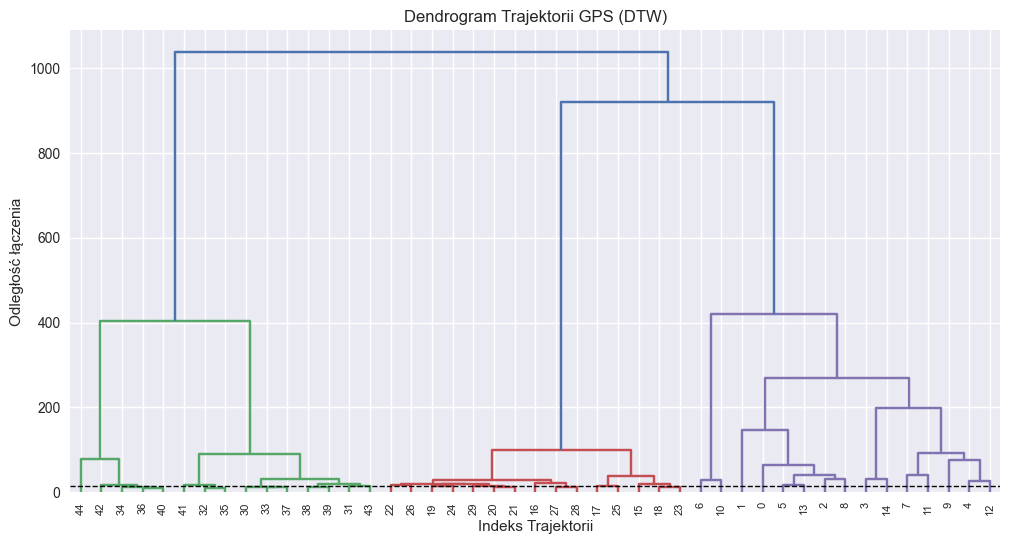

In [11]:
trajectories = generate_trajectories()
n = len(trajectories)
dtw_matrix = compute_dtw_matrix(trajectories)



condensed_dist = squareform(dtw_matrix)
Z = linkage(condensed_dist, method='ward')

plt.figure(figsize=(12, 6))
plt.title("Dendrogram Trajektorii GPS (DTW)")
dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=8.,
)
plt.xlabel("Indeks Trajektorii")
plt.ylabel("Odległość łączenia")
plt.axhline(y=15, c='k', ls='--', lw=1, label='')
plt.show()

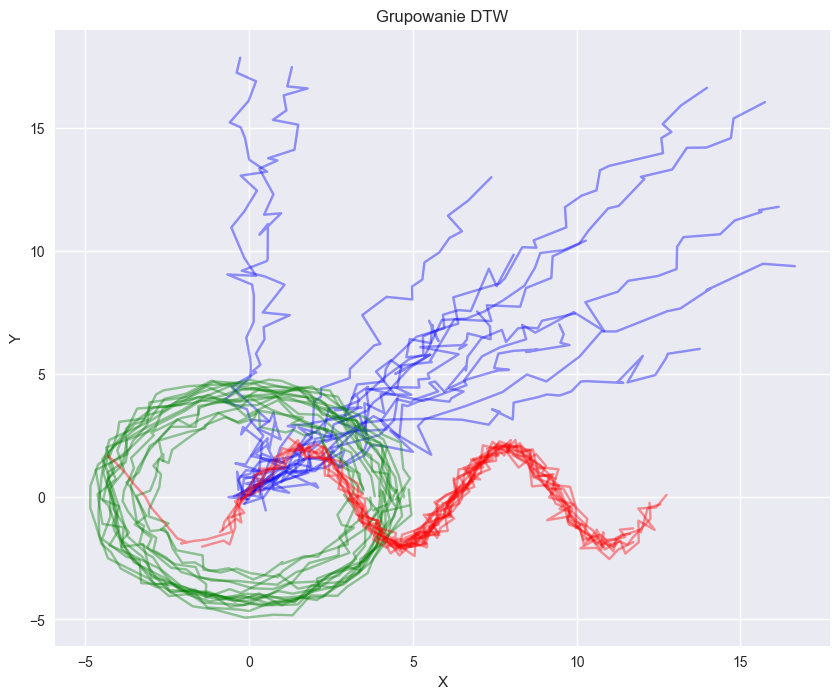

In [12]:
labels = fcluster(Z, t = 3, criterion="maxclust") # 3 grupy
plt.figure(figsize=(10, 8))
colors = ['r', 'g', 'b']

for i, traj in enumerate(trajectories):
    cluster_id = labels[i]
    color = colors[cluster_id - 1] # 1 -> r, 2 -> g, 3 -> b
    plt.plot(traj[:, 0], traj[:, 1], c=color, alpha=0.4)

plt.title("Grupowanie DTW")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()